## gwModelRemSE : remnant properties of eccentric non-precessing BBH mergers

`gwModelRemSE` extends the quasi-circular aligned-spin baseline `gwModelRemS`
with a multiplicative correction in the reference eccentricity and mean anomaly,
both specified at $t = -2500M$ before merger. Inputs are
$(q, \chi_{1z}, \chi_{2z}, e_{\rm ref}, \ell_{\rm ref})$.

Every quantity $X$ is corrected as

$$X\big|_{\rm ecc} = X^{\rm circ}\left[1 + \mathcal{P}_X\left(1 + \alpha_X e_{\rm ref} T_X(\ell_{\rm ref} + \varphi_X)\right)\right]$$

with $\mathcal{P}_X = (a_1 + b_1\eta)e_{\rm ref} + (a_2 + b_2\eta)e_{\rm ref}^2$
and harmonics $T_M = \sin$, $T_\chi = \cos$, $T_k = \cos$, $T_L = -\sin$.

> **This model is provisional.** The circular limit is exact, but at
> $e_{\rm ref} > 0$ it does not yet improve on the quasi-circular baseline on NR
> data, and it degrades sharply beyond $e_{\rm ref} \sim 0.3$. Section 5 shows
> this explicitly. Calibrated for $q \le 4$, $e_0 \le 0.25$, non-spinning.

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Basic evaluation

In [2]:
q, chi1z, chi2z = 2.0, 0.0, 0.0
e_ref, l_ref = 0.1, 0.0

Mf, chif, vkick, Lpeak = gwModels.remnants.gwModelRemSE(q, chi1z, chi2z, e_ref, l_ref)

print(f'q = {q}, chi1z = {chi1z}, chi2z = {chi2z}')
print(f'e_ref = {e_ref}, l_ref = {l_ref}')
print()
print(f'  Mf/M           = {Mf:.6f}')
print(f'  chi_f,z        = {chif:.6f}')
print(f'  v_kick [km/s]  = {vkick:.3f}')
print(f'  L_peak [c^5/G] = {Lpeak:.6e}')

q = 2.0, chi1z = 0.0, chi2z = 0.0
e_ref = 0.1, l_ref = 0.0

  Mf/M           = 0.961463
  chi_f,z        = 0.623274
  v_kick [km/s]  = 153.683
  L_peak [c^5/G] = 7.713974e-04


### 2. The circular limit is exact\n\nAt $e_{\rm ref} = 0$ the polynomial $\mathcal{P}_X$ vanishes identically, so the model returns the `gwModelRemS` values bit-for-bit and is independent of the mean anomaly.

In [3]:
se = gwModels.remnants.gwModelRemSE(2.0, 0.3, 0.1, 0.0, 0.0)
s = gwModels.remnants.gwModelRemS(2.0, 0.3, 0.1)

print('  quantity      gwModelRemS            gwModelRemSE (e=0)     exact')
print(f'  Mf         {s[0]:.15f}   {se[0]:.15f}   {se[0] == s[0]}')
print(f'  chif       {s[1]:.15f}   {se[1]:.15f}   {se[1] == s[1]}')
print(f'  vkick      {s[4]:15.9f}   {se[2]:15.9f}   {se[2] == s[4]}')
print(f'  Lpeak      {s[2]:.9e}       {se[3]:.9e}       {se[3] == s[2]}')

print()
vals = [gwModels.remnants.gwModelRemSE_mf(3.0, 0.2, 0.1, 0.0, l)
        for l in [0.0, 1.0, np.pi, 5.5]]
print(f'  independent of l_ref at e=0 : {len(set(vals)) == 1}')

  quantity      gwModelRemS            gwModelRemSE (e=0)     exact
  Mf         0.954874940720620   0.954874940720620   True
  chif       0.723490977149941   0.723490977149941   True
  vkick         87.574576730      87.574576730   True
  Lpeak      8.906450500e-04       8.906450500e-04       True

  independent of l_ref at e=0 : True


### 3. Eccentricity and anomaly dependence

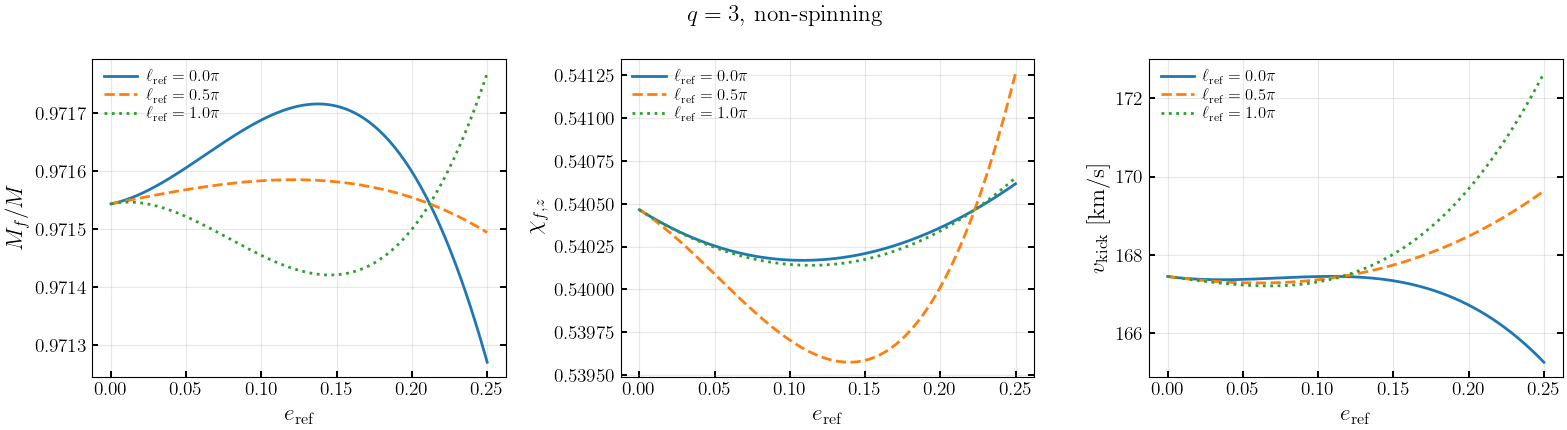

In [4]:
e_arr = np.linspace(0, 0.25, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for l_fix, ls in [(0.0, '-'), (np.pi / 2, '--'), (np.pi, ':')]:
    Mf, chif, vk, Lp = gwModels.remnants.gwModelRemSE(3.0, 0.0, 0.0, e_arr, l_fix)
    lab = rf'$\ell_{{\rm ref}} = {l_fix/np.pi:.1f}\pi$'
    axes[0].plot(e_arr, Mf, ls, lw=2, label=lab)
    axes[1].plot(e_arr, chif, ls, lw=2, label=lab)
    axes[2].plot(e_arr, vk, ls, lw=2, label=lab)

for ax, lab in zip(axes, ['$M_f/M$', r'$\chi_{f,z}$', r'$v_{\rm kick}$ [km/s]']):
    ax.set_xlabel(r'$e_{\rm ref}$')
    ax.set_ylabel(lab)
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle(r'$q=3$, non-spinning')
plt.tight_layout()
plt.show()

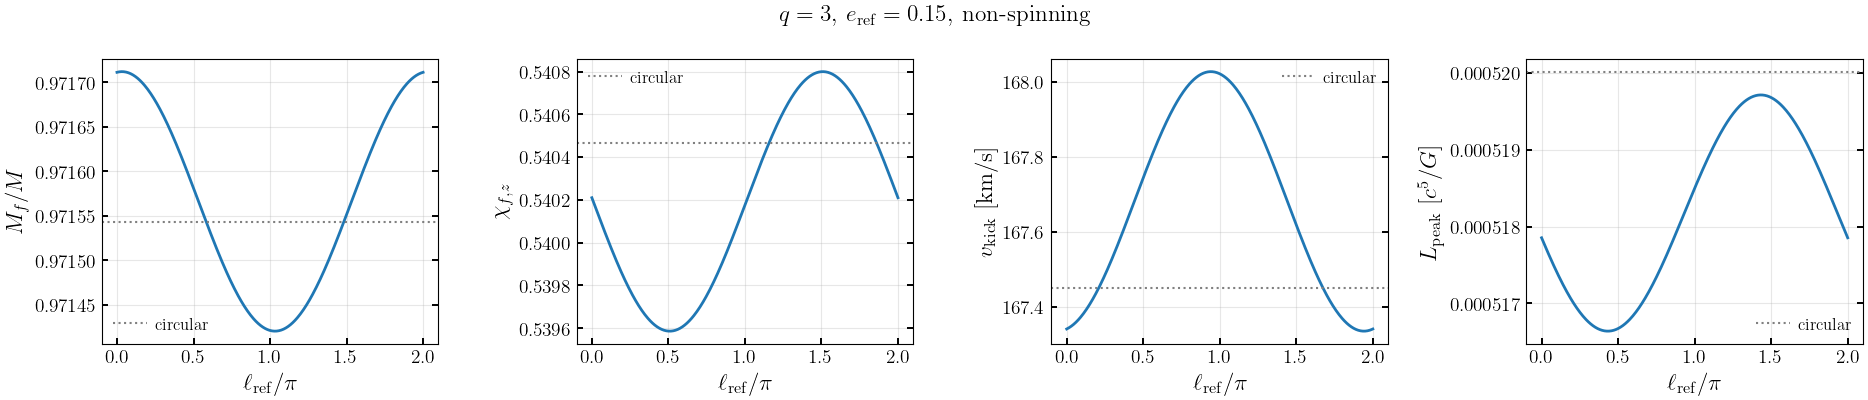

In [5]:
# Anomaly modulation at fixed eccentricity: sin for the mass, cos for the
# spin and recoil, -sin for the luminosity
l_arr = np.linspace(0, 2 * np.pi, 400)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
q_e, e_fix = 3.0, 0.15
Mf, chif, vk, Lp = gwModels.remnants.gwModelRemSE(q_e, 0.0, 0.0, e_fix, l_arr)
Mf0, chif0, Lp0, _, vk0 = gwModels.remnants.gwModelRemS(q_e, 0.0, 0.0)

for ax, y, y0, lab in [
    (axes[0], Mf, Mf0, '$M_f/M$'),
    (axes[1], chif, chif0, r'$\chi_{f,z}$'),
    (axes[2], vk, vk0, r'$v_{\rm kick}$ [km/s]'),
    (axes[3], Lp, Lp0, r'$L_{\rm peak}$ [$c^5/G$]'),
]:
    ax.plot(l_arr / np.pi, y, lw=2)
    ax.axhline(y0, color='grey', ls=':', lw=1.5, label='circular')
    ax.set_xlabel(r'$\ell_{\rm ref}/\pi$')
    ax.set_ylabel(lab)
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle(rf'$q={q_e:.0f}$, $e_{{\rm ref}}={e_fix}$, non-spinning')
plt.tight_layout()
plt.show()

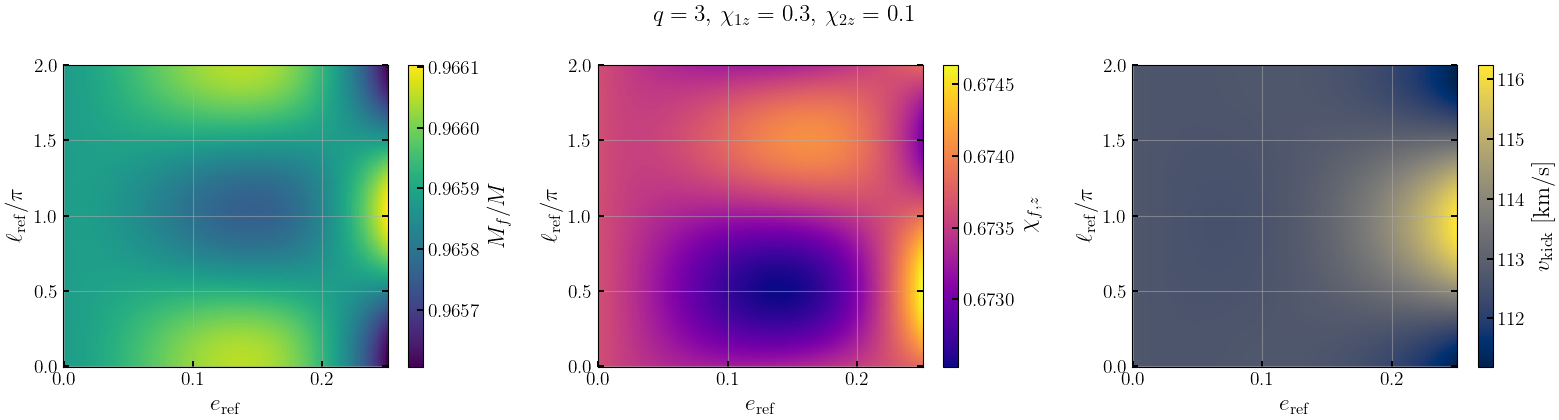

In [6]:
# Two-dimensional map over (e_ref, l_ref)
e_g = np.linspace(0, 0.25, 200)
l_g = np.linspace(0, 2 * np.pi, 200)
E, L = np.meshgrid(e_g, l_g)

MF, CF, VK, LP = gwModels.remnants.gwModelRemSE(3.0, 0.3, 0.1, E, L)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, Z, lab, cmap in [
    (axes[0], MF, '$M_f/M$', 'viridis'),
    (axes[1], CF, r'$\chi_{f,z}$', 'plasma'),
    (axes[2], VK, r'$v_{\rm kick}$ [km/s]', 'cividis'),
]:
    im = ax.pcolormesh(E, L / np.pi, Z, shading='auto', cmap=cmap)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(lab)
    ax.set_xlabel(r'$e_{\rm ref}$')
    ax.set_ylabel(r'$\ell_{\rm ref}/\pi$')

plt.suptitle(r'$q=3$, $\chi_{1z}=0.3$, $\chi_{2z}=0.1$')
plt.tight_layout()
plt.show()

### 4. Optional Kerr separatrix backbone\n\nThe calibrated model applies its correction directly to the circular baseline. `Kerr.py` additionally provides the eccentric separatrix quantities, for users who wish to experiment with a separatrix-anchored point-particle backbone. They reduce to the Kerr ISCO as $e_s \to 0$.

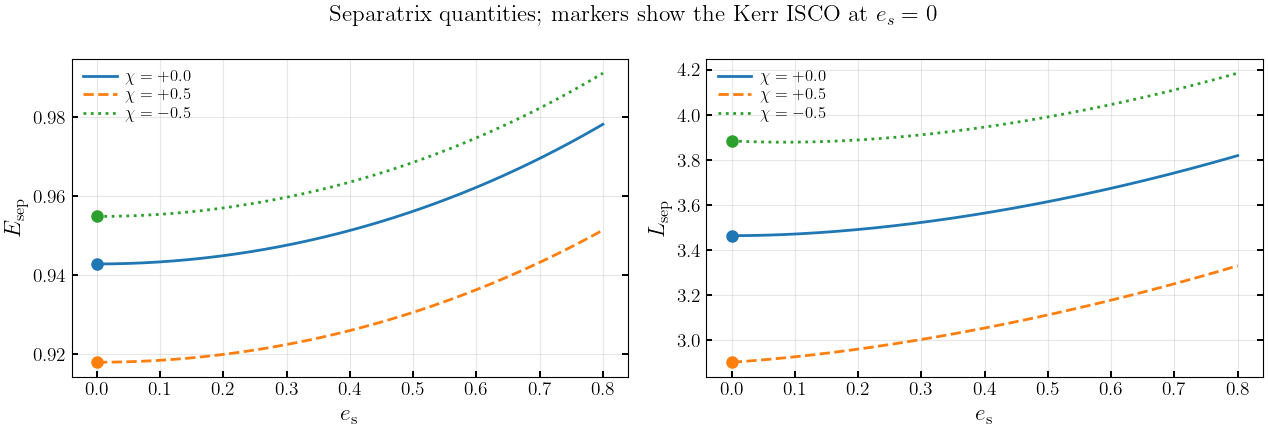

In [7]:
e_s = np.linspace(0, 0.8, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for chi_s, ls in [(0.0, '-'), (0.5, '--'), (-0.5, ':')]:
    axes[0].plot(e_s, gwModels.remnants.separatrix_energy(e_s, chi_s), ls, lw=2,
                 label=rf'$\chi = {chi_s:+.1f}$')
    axes[1].plot(e_s, gwModels.remnants.separatrix_angular_momentum(e_s, chi_s), ls,
                 lw=2, label=rf'$\chi = {chi_s:+.1f}$')

for chi_s, c in [(0.0, 'C0'), (0.5, 'C1'), (-0.5, 'C2')]:
    axes[0].plot(0, gwModels.remnants.kerr_isco_energy(chi_s), 'o', color=c, ms=8)
    axes[1].plot(0, gwModels.remnants.kerr_isco_angular_momentum(chi_s), 'o', color=c, ms=8)

axes[0].set_ylabel(r'$E_{\rm sep}$')
axes[1].set_ylabel(r'$L_{\rm sep}$')
for ax in axes:
    ax.set_xlabel(r'$e_{\rm s}$')
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle(r'Separatrix quantities; markers show the Kerr ISCO at $e_s=0$')
plt.tight_layout()
plt.show()

### 5. Domain of validity, and a caution\n\nThe anomaly modulation enters as $\alpha_X e_{\rm ref}$ with $\alpha_M \approx 42$, so the correction grows linearly with eccentricity. Well inside the calibration range this is a small perturbation; beyond $e_{\rm ref} \sim 0.3$ it becomes larger than the quantity it is correcting.

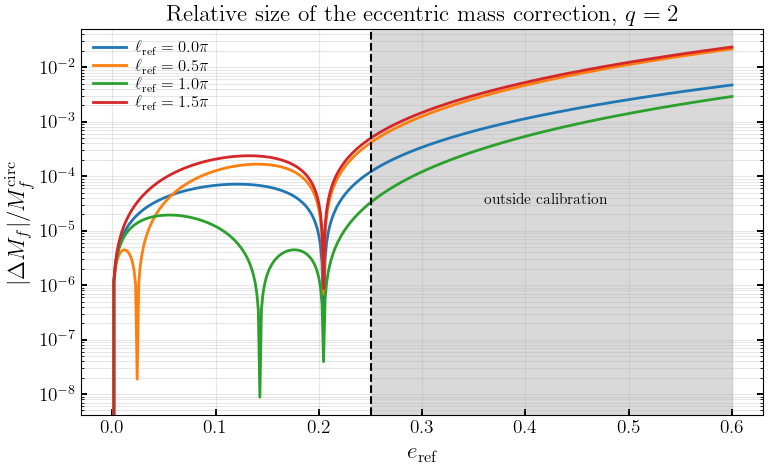

In [8]:
# Size of the eccentric correction relative to the circular value
e_wide = np.linspace(0, 0.6, 400)
q_w = 2.0

Mf0 = gwModels.remnants.gwModelRemS_mf(q_w, 0.0, 0.0)
frac = []
for l_fix in [0.0, np.pi / 2, np.pi, 3 * np.pi / 2]:
    Mf = gwModels.remnants.gwModelRemSE_mf(q_w, 0.0, 0.0, e_wide, l_fix)
    frac.append(np.abs(Mf - Mf0) / Mf0)

plt.figure(figsize=(8, 5))
for f, l_fix in zip(frac, [0.0, 0.5, 1.0, 1.5]):
    plt.semilogy(e_wide, f, lw=2, label=rf'$\ell_{{\rm ref}} = {l_fix:.1f}\pi$')

plt.axvspan(0.25, 0.6, color='0.85', zorder=0)
plt.text(0.42, 3e-5, 'outside calibration', ha='center', fontsize=11)
plt.axvline(0.25, color='k', ls='--', lw=1.5)
plt.xlabel(r'$e_{\rm ref}$')
plt.ylabel(r'$|\Delta M_f| / M_f^{\rm circ}$')
plt.title(rf'Relative size of the eccentric mass correction, $q={q_w:.0f}$')
plt.legend(frameon=False)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [9]:
# Measured performance against the 276-simulation SXS+RIT eccentric set.
# Negative means the eccentric correction increases the residual scatter.
print('  cut                        N     Mass     Spin     Kick     Lumi')
print('  all (e <= 0.58)          276   -246%    -117%     -20%     -10%')
print('  e <= 0.30                219   -16.0%    -3.4%    -0.9%    -0.5%')
print('  e <= 0.25 (calib limit)  195    -7.5%    -3.0%    -0.1%    -0.5%')
print('  e <= 0.25 and q <= 4     160    -8.0%    -2.2%    -0.3%    -0.4%')
print('  e <= 0.05                 32    -0.4%   -12.3%    -0.8%    +0.8%')
print()
print('  The headline -246% is an extrapolation artifact: 29% of that set lies')
print('  beyond the calibrated e0 <= 0.25 and drives nearly all of it. Inside')
print('  the calibration domain the model is neutral to a few percent worse.')
print('  Treat gwModelRemSE as provisional and do not run it past e ~ 0.3.')

  cut                        N     Mass     Spin     Kick     Lumi
  all (e <= 0.58)          276   -246%    -117%     -20%     -10%
  e <= 0.30                219   -16.0%    -3.4%    -0.9%    -0.5%
  e <= 0.25 (calib limit)  195    -7.5%    -3.0%    -0.1%    -0.5%
  e <= 0.25 and q <= 4     160    -8.0%    -2.2%    -0.3%    -0.4%
  e <= 0.05                 32    -0.4%   -12.3%    -0.8%    +0.8%

  The headline -246% is an extrapolation artifact: 29% of that set lies
  beyond the calibrated e0 <= 0.25 and drives nearly all of it. Inside
  the calibration domain the model is neutral to a few percent worse.
  Treat gwModelRemSE as provisional and do not run it past e ~ 0.3.


### 6. Timing

In [10]:
sizes = [1, 10, 100, 1000, 10000, 100000]
means = []

for n in sizes:
    q_t = np.random.uniform(1, 4, n)
    c1_t = np.random.uniform(-0.5, 0.5, n)
    c2_t = np.random.uniform(-0.5, 0.5, n)
    e_t = np.random.uniform(0, 0.25, n)
    l_t = np.random.uniform(0, 2 * np.pi, n)
    reps = 20 if n <= 10000 else 5
    t = []
    for _ in range(reps):
        t0 = time.perf_counter()
        gwModels.remnants.gwModelRemSE(q_t, c1_t, c2_t, e_t, l_t)
        t.append(time.perf_counter() - t0)
    means.append(np.mean(t))

means = np.array(means)
print(f'{'N':>8s}  {'time':>10s}  {'per binary':>13s}')
for n, m in zip(sizes, means):
    print(f'{n:>8d}  {m*1e3:8.3f} ms  {m/n*1e6:10.4f} us')

       N        time     per binary
       1     0.268 ms    268.0542 us
      10     0.272 ms     27.2015 us
     100     0.300 ms      3.0000 us
    1000     0.542 ms      0.5420 us
   10000     3.320 ms      0.3320 us
  100000    34.191 ms      0.3419 us


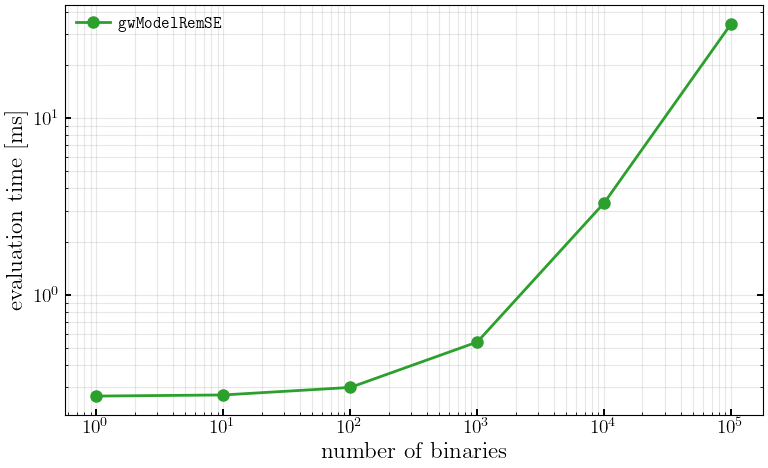

In [11]:
plt.figure(figsize=(8, 5))
plt.loglog(sizes, means * 1e3, 'o-', lw=2, ms=8, color='C2',
           label=r'\texttt{gwModelRemSE}')
plt.xlabel('number of binaries')
plt.ylabel('evaluation time [ms]')
plt.legend(frameon=False)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()